# Ciclos limite

Un ciclo limite es una solucion aislada al sistema de ecuaciones

## Ejemplo

$$
\begin{cases}
\dot{r} = r(1 - r^2), \\
\dot{\theta} = 1.
\end{cases}
$$


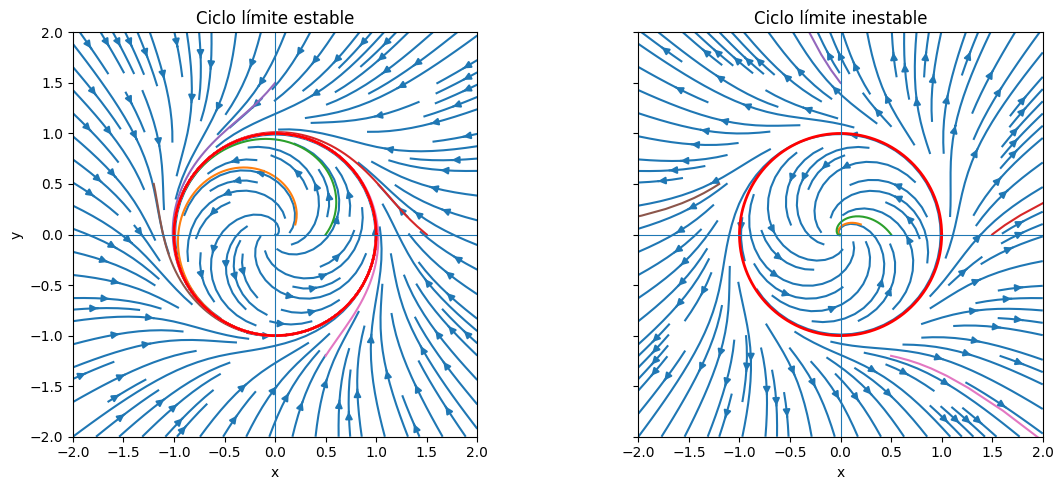

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =========================
# Definición de sistemas
# =========================
def sistema_estable(t, z):
    x, y = z
    r2 = x**2 + y**2
    return [(1 - r2)*x - y,
            (1 - r2)*y + x]

def sistema_inestable(t, z):
    x, y = z
    r2 = x**2 + y**2
    return [(r2 - 1)*x - y,
            (r2 - 1)*y + x]

# =========================
# Mallado del campo vectorial
# =========================
x = np.linspace(-2, 2, 30)
y = np.linspace(-2, 2, 30)
X, Y = np.meshgrid(x, y)

Ue = (1 - X**2 - Y**2)*X - Y
Ve = (1 - X**2 - Y**2)*Y + X

Ui = (X**2 + Y**2 - 1)*X - Y
Vi = (X**2 + Y**2 - 1)*Y + X

# =========================
# Condiciones iniciales
# =========================
condiciones = [
    [0.2, 0.1], [0.5, 0], [1.5, 0],
    [0, 1.5], [-1.2, 0.5], [0.5, -1.2]
]

# =========================
# Gráficas
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# ---- Ciclo estable ----
ax = axes[0]
ax.streamplot(X, Y, Ue, Ve, density=1.2)
for z0 in condiciones:
    sol = solve_ivp(sistema_estable, [0, 30], z0, max_step=0.05)
    ax.plot(sol.y[0], sol.y[1])
ax.plot(np.cos(np.linspace(0, 2*np.pi, 400)),
        np.sin(np.linspace(0, 2*np.pi, 400)),
        'r', linewidth=2)
ax.set_title("Ciclo límite estable")
ax.set_xlabel("x")
ax.set_ylabel("y")

# ---- Ciclo inestable ----
ax = axes[1]
ax.streamplot(X, Y, Ui, Vi, density=1.2)
for z0 in condiciones:
    sol = solve_ivp(sistema_inestable, [0, 30], z0, max_step=0.05)
    ax.plot(sol.y[0], sol.y[1])
ax.plot(np.cos(np.linspace(0, 2*np.pi, 400)),
        np.sin(np.linspace(0, 2*np.pi, 400)),
        'r', linewidth=2)
ax.set_title("Ciclo límite inestable")
ax.set_xlabel("x")

# Ajustes finales
for ax in axes:
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.set_aspect("equal")
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

plt.tight_layout()
plt.show()


### Criterios para ver que no hay ciclos límite  
**Criterio de Bendixson–Dirack**

Sea $f : \mathbb{R}^2 \to \mathbb{R}^2$ continua y diferenciable en  
$B \subset \mathbb{R}^2$ y existe una función diferenciable  
$g : \mathbb{R}^2 \to \mathbb{R}$ tal que

$$
\nabla \cdot (g f) = \frac{\partial (g f_1)}{\partial x}
+ \frac{\partial (g f_2)}{\partial y}
$$

no cambia de signo en $B$.  
Entonces el sistema

$$
\dot{x} = f(x)
$$

no tiene soluciones periódicas en $B$.

---

### Demostración

Supongamos que el sistema $\dot{x} = f(x)$ tiene una solución periódica
con trayectoria cerrada $C$, y sea $A$ la región encerrada por $C$.

Entonces,

$$
\iint_A \nabla \cdot (g f)\, dA
= \oint_C (g f)\cdot \vec{n}\, ds
$$

pero como $C$ es una trayectoria del sistema,

$$
\oint_C g\, f \cdot \vec{n}\, ds
= \oint_C g\, (\dot{x}\cdot \vec{n})\, ds = 0.
$$

Esto contradice que $\nabla \cdot (g f)$ no cambie de signo en $B$.

Por lo tanto, el sistema no puede tener soluciones periódicas.


### Ejemplo

Consideremos el sistema

$$
\begin{cases}
\dot{x} = x(2 - x - y), \\
\dot{y} = y(4x - x^2 - 3).
\end{cases}
$$

Tomamos como función de Dirack

$$
g(x,y) = \frac{1}{xy}.
$$

Entonces,

$$
g f =
\left(
\frac{x(2 - x - y)}{xy},
\frac{y(4x - x^2 - 3)}{xy}
\right)
=
\left(
\frac{2 - x - y}{y},
\frac{4x - x^2 - 3}{x}
\right).
$$

Calculamos la divergencia:

$$
\operatorname{div}(g f)
= \nabla \cdot (g f)
= \frac{\partial}{\partial x}\!\left(\frac{2 - x - y}{y}\right)
+ \frac{\partial}{\partial y}\!\left(\frac{4x - x^2 - 3}{x}\right)
= -\frac{1}{y}.
$$

Como $\operatorname{div}(g f)$ no cambia de signo en los semiplanos
$y > 0$ y $y < 0$, concluimos que **no existen soluciones periódicas**
en dichos semiplanos.


### Ejemplo II

Consideremos el sistema

$$
\begin{cases}
\dot{x} = y, \\
\dot{y} = -x - y + x^2 + y^2.
\end{cases}
$$

Tomamos la función

$$
g(x,y) = e^{-2x}.
$$

Entonces,

$$
g f =
\left(
y e^{-2x},
e^{-2x}(-x - y + x^2 + y^2)
\right).
$$

Calculamos la divergencia:

$$
\begin{aligned}
\operatorname{div}(g f)
&= \frac{\partial}{\partial x}\left(y e^{-2x}\right)
 + \frac{\partial}{\partial y}\left(e^{-2x}(-x - y + x^2 + y^2)\right) \\
&= -2y e^{-2x} + e^{-2x}(-1 + 2y) \\
&= -e^{-2x} < 0, \qquad \forall (x,y) \in \mathbb{R}^2.
\end{aligned}
$$

---

### Teorema de Poincaré–Bendixson

Sea $f : \mathbb{R}^2 \to \mathbb{R}^2$ continua y diferenciable.  
Sea $B \subset \mathbb{R}^2$ un conjunto conexo tal que $f(x) \neq 0$ para todo
$x \in B$.

Si para algún $y_0 \in B$, las soluciones $x(t)$ del problema

$$
\begin{cases}
\dot{x} = f(x), \\
x(0) = y_0,
\end{cases}
$$

son tales que $x(t) \in B$ para todo $t > 0$, entonces **existe un ciclo límite**
contenido en $B$.


### Ejemplo

Sea el sistema en coordenadas polares

$$
\begin{cases}
\dot r = r(1 - r^2) + \mu r \cos\theta, \\
\dot \theta = 1.
\end{cases}
$$

Como

$$
\dot\theta > 0,
$$

las soluciones **rotan hacia la izquierda**.

---

Analizamos el signo de $\dot r$.

Si $r > \sqrt{1 + \mu}$, entonces

$$
r(1 - r^2) + \mu r \cos\theta
\le r(1 - r^2) + \mu r
= r(1 - r^2 + \mu) < 0.
$$

Por lo tanto, para

$$
r > \sqrt{1 + \mu},
$$

las trayectorias apuntan **hacia adentro**.

---

Por otro lado, si

$$
r < \sqrt{1 - \mu},
$$

entonces

$$
r(1 - r^2) + \mu r \cos\theta
\ge r(1 - r^2) - \mu r
= r(1 - r^2 - \mu) > 0.
$$

Es decir, para

$$
r < \sqrt{1 - \mu},
$$

las trayectorias apuntan **hacia afuera**.

---

### Conclusión

Entre los radios

$$
\sqrt{1 - \mu} < r < \sqrt{1 + \mu},
$$

las trayectorias quedan atrapadas en un anillo, lo que garantiza la existencia
de un **ciclo límite**.
